In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox
from tkinter import *

In [110]:
df = pd.read_csv('data_pasien_new.csv')

In [111]:
df = df.drop('Unnamed: 0', axis=1)

## Model

In [112]:
X = df.drop('target', axis=1)
y = df['target']

In [113]:
def split(X, y, size=0.8):
    np.random.seed(42)

    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    train_0 = int(len(idx_0) * size)
    train_1 = int(len(idx_1) * size)

    train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
    test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    return X_train, y_train, X_test, y_test

In [114]:
X_train, y_train, X_test, y_test = split(X, y, size=0.8)

In [115]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(241, 13)
(241,)
(61, 13)
(61,)


In [116]:
def gini_impurity(group, classes):
    n_isintance = float(sum([len(group) for group in group]))
    gini = 0.0

    for group in group:
        size = float(len(group))
        if size == 0:
            continue

        score = 0.0
        y_group =  group.iloc[:, -1]

        for class_val in classes:
            p = (y_group == class_val).sum() / size
            score += p ** 2
        gini += (1.0 - score) * (size / n_isintance)

    return gini

In [117]:
def split_dt(data, feature, threshold):
    left = data[data.iloc[:, feature] < threshold]
    right = data[data.iloc[:, feature] >= threshold]

    return left, right

In [118]:
def best_split(data, classes):
    best_gini = float('inf')
    best_split = {}
    n_feature = data.shape[1] - 1

    for feature_idx in range(n_feature):
        for index, row in data.iterrows():
            group = split_dt(data, feature_idx, row.iloc[feature_idx])
            gini = gini_impurity(group, classes)

            if gini < best_gini:
                best_gini = gini
                best_split = {
                    'feature_idx': feature_idx,
                    'val': row.iloc[feature_idx],
                    'group': group}
    return best_split

In [119]:
def terminal(group):
    return (group.iloc[:, -1].mode()[0])

def build_tree(data, classes, depth, max_depth):
    root = best_split(data, classes)
    if not root:
        return terminal(data)

    left, right = root['group']
    del(root['group'])

    if len(left) == 0 or len(right) == 0:
        no_split = pd.concat([left, right])
        root['left'] = root['right'] = terminal(no_split) 
        return root

    if depth >= max_depth :
        root['left'] = terminal(left)  
        root['right'] = terminal(right)
        return root
    
    root['left'] = build_tree(left, classes, depth + 1 , max_depth)
    root['right'] = build_tree(right, classes, depth + 1 , max_depth)
    return root

In [120]:
def predict_row(node, row):
    if not isinstance(node, dict):
        return node
    
    if row.iloc[node['feature_idx']] < node['val']:
        return predict_row(node['left'], row)
    else:
        return predict_row(node['right'], row)

def predict_batch(tree, data_test):
    predictions = []
    for index, row in data_test.iterrows():
        prediction = predict_row(tree, row)
        predictions.append(prediction)
    return predictions

In [121]:
def depth_search(X_train, y_train, X_test, y_test, depths):
    best_depth = None
    best_acc = 0
    accuracy = []

    train_data = pd.concat([X_train, y_train], axis=1)
    classes = y_train.unique()

    for range_depth in depths:
        tree = build_tree(train_data, classes, depth=0, max_depth=range_depth)
        y_pred = predict_batch(tree, X_test)
        acc = np.mean(y_test == y_pred)
        accuracy.append(acc)

        print(f'Depth: {range_depth} - Akurasi: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            best_depth = range_depth
    print(f'Best Depth: {best_depth} - Akurasi: {accuracy}')

    return best_depth, best_acc

In [142]:
best_depth, best_acc = depth_search(X_train, y_train, X_test, y_test, depths=range(1,11))

Depth: 1 - Akurasi: 0.6885
Depth: 2 - Akurasi: 0.7541
Depth: 3 - Akurasi: 0.8033
Depth: 4 - Akurasi: 0.7869
Depth: 5 - Akurasi: 0.7541
Depth: 6 - Akurasi: 0.7541
Depth: 7 - Akurasi: 0.7049
Depth: 8 - Akurasi: 0.7049
Depth: 9 - Akurasi: 0.7049
Depth: 10 - Akurasi: 0.7049
Best Depth: 3 - Akurasi: [np.float64(0.6885245901639344), np.float64(0.7540983606557377), np.float64(0.8032786885245902), np.float64(0.7868852459016393), np.float64(0.7540983606557377), np.float64(0.7540983606557377), np.float64(0.7049180327868853), np.float64(0.7049180327868853), np.float64(0.7049180327868853), np.float64(0.7049180327868853)]


In [143]:
best_depth

3

In [144]:
train_data = pd.concat([X_train, y_train], axis=1)
unique_classes = y_train.unique()
my_tree = build_tree(train_data, unique_classes, depth=0, max_depth=best_depth)

predicxtion_test = predict_batch(my_tree, X_test)
predicxtion_train = predict_batch(my_tree, X_train)

In [179]:
def evaluasi(y_trues, y_preds):
    y_true = np.array(y_trues)
    y_pred = np.array(y_preds)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = np.sum(y_true == y_pred) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f'Akurasi : {accuracy:.2%}')
    print(f'Presisi : {precision:.2%}')
    print(f'Recall  : {recall:.2%}')
    print(f'F1      : {f1:.2%}\n')

    return precision, recall, f1

In [189]:
print("-- Evaluasi Model --")
print("\n-- Data Train -- ")
precision_train, recall_train, f1_train = evaluasi(y_train, predicxtion_train)
print("-- Data Test --")
precision_test, recall_test, f1_test = evaluasi(y_test, predicxtion_test)

-- Evaluasi Model --

-- Data Train -- 
Akurasi : 90.04%
Presisi : 86.39%
Recall  : 96.95%
F1      : 91.37%

-- Data Test --
Akurasi : 80.33%
Presisi : 74.42%
Recall  : 96.97%
F1      : 84.21%



model bekerja dengan sangat baik dengan akurasi Test 80%. Model tidak begitu overfit dengan selisih akurasi train dan test tidak begitu ekstrim. Pada dataset ini, Recall pada data Test mencapai 96% dimana model cukup baik menyaring seseorang yang sehat namun sakit. Alasan kami memakai hasil dari Recall untuk patokan bahwa model ini baik atau tidak dalam menangani dataset karena semakin besar nilai Recall maka False Negatif (memprediksi pasien yang sehat namun ternyata dia sakit) semakin kecil.

In [150]:
# fungsi cm
def visualize_matrix(y_true, y_pred, data_name):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes), dtype=int)

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i,j] = np.sum((y_true == c_true) & (y_pred == c_pred))
    
    labels = ['Sehat (0)', 'Sakit (1)']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, 
                yticklabels=labels)
    
    plt.title(f'Confusion Matrix Model - Data {data_name}')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Actual')
    plt.show()

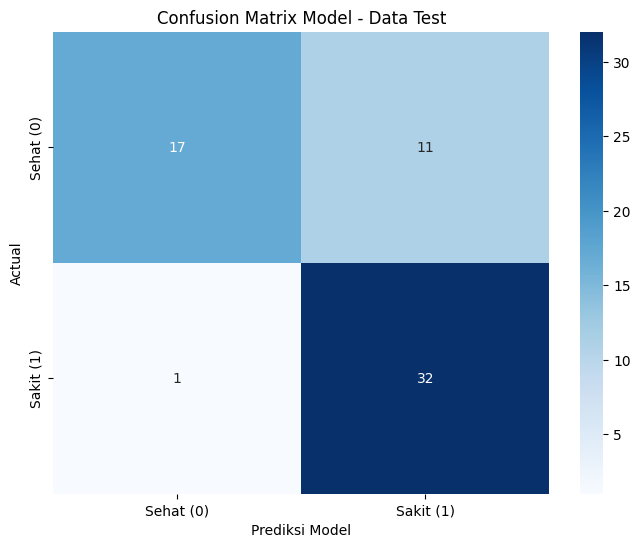

In [151]:
visualize_matrix(y_test, predicxtion_test, 'Test')


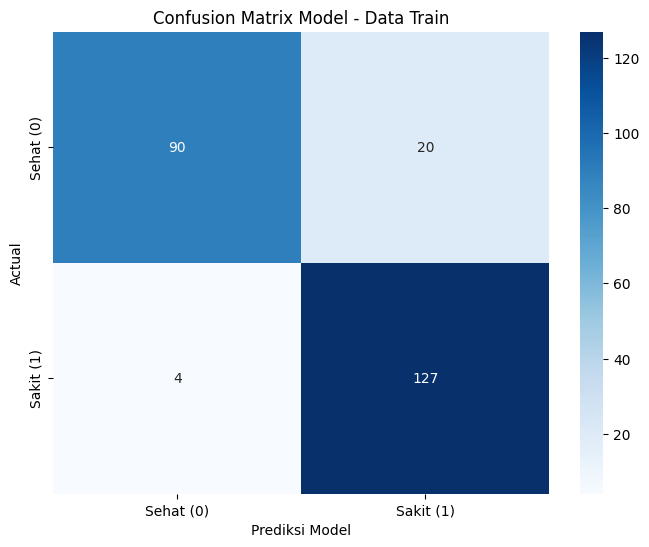

In [152]:
visualize_matrix(y_train, predicxtion_train, 'Train')


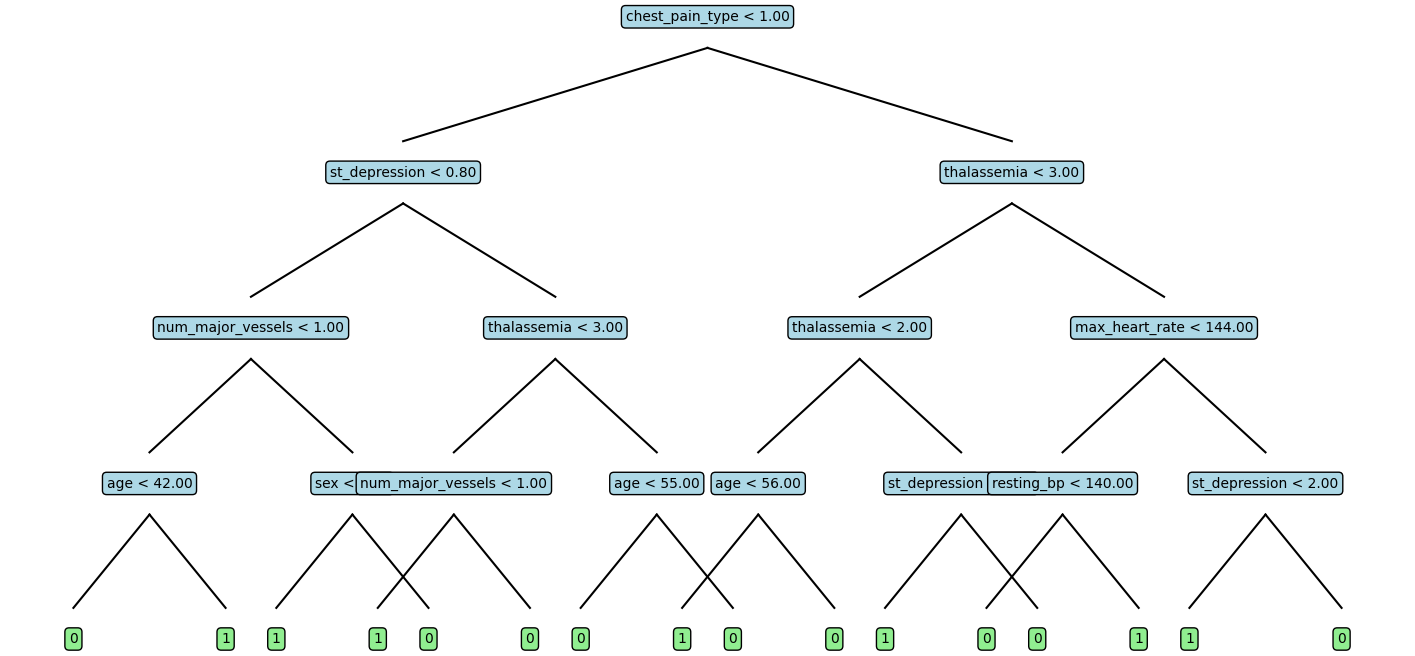

In [153]:
# visualize tree node
def visualize_tree(tree, feature_name, depth=0, x=0.5, y=1.0, dx=0.25):
    if not isinstance(tree, dict):
        plt.text(x, y, str(tree), ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightgreen'))
        return

    plt.text(x, y, f"{feature_name[tree['feature_idx']]} < {tree['val']:.2f}", ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightblue'))

    # Draw left subtree
    visualize_tree(tree['left'], feature_name, depth + 1, x - dx / (depth + 1), y - 0.1, dx)
    plt.plot([x, x - dx / (depth + 1)], [y - 0.02, y - 0.08], 'k-')

    # Draw right subtree
    visualize_tree(tree['right'], feature_name, depth + 1, x + dx / (depth + 1), y - 0.1, dx)
    plt.plot([x, x + dx / (depth + 1)], [y - 0.02, y - 0.08], 'k-')

plt.figure(figsize=(18, 8))
visualize_tree(my_tree, X.columns)
plt.axis('off')
plt.show()

In [208]:
feature_col = X.columns
n_col = len(feature_col)

# Fungsi Button
def on_submit():
    try:
        input_data = []
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)

        input_df = pd.DataFrame([input_data], columns=feature_col)
        prediction = predict_batch(my_tree, input_df)[0]

        if prediction == 1:
            result_text = "Pasien Terjangkit Penyakit Jantung"
        else:
            result_text = "Pasien Tidak Terjangkit Penyakit Jantung"
        messagebox.showinfo("Hasil Prediksi", result_text)
    except ValueError:
        messagebox.showerror("Input Error", "Masukan Data Yang Valid!.")

# Main Gui
root = tk.Tk()
root.title("Prediksi Pasien Penyakit Jantung")
root.configure(bg='#EAEAEA')
entries = []

# Title
title_label = tk.Label(root,
                       text="Prediksi Penyakit Jantung",
                       font=("Arial", 25, 'bold'),
                       bg="#EAEAEA",
                       fg="#AA495F")
title_label.pack(pady=10)


# Kolom dan Entry
for i in range(n_col):
    frame = tk.Frame(root)
    frame.place(relx=0.5, rely=0.05 + i*0.06, anchor='center')
    frame.configure(bg='#EAEAEA')
    frame.pack()

    label = tk.Label(frame, text=feature_col[i],
                     font=("Arial", 10),
                     bg="#EAEAEA",
                     fg='#141414')
    label.pack()

    entry = tk.Entry(frame)
    entry.pack(side=tk.RIGHT)
    entries.append(entry)

# button submit
submit_button = tk.Button(root,
                          text="Submit",
                          font=("Arial", 18, 'bold'),
                          bg="#D23252",
                          fg="#F4F4F4",
                          command=on_submit,
                          activebackground="#97233E",
                          activeforeground="#F4F4F4")
submit_button.pack(pady=10)
root.mainloop()


In [132]:
df.sample(5)

,age,sex,chest_pain_type,resting_bp,cholestrol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
49,53,0,0,138,234,0,0,160,0,0.0,2,0,2,1
58,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
181,61,0,0,130,330,0,0,169,0,0.0,2,0,2,0
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
23,61,1,2,150,243,1,1,137,1,1.0,1,0,2,1
